# LVIS v1 Dataset Exploration

## Section 1: Import Required Libraries

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os
import random
from collections import defaultdict, Counter
import seaborn as sns
from pathlib import Path

## Section 2: Load LVIS Annotations

In [3]:
with open("lvis_v1_train.json", 'r') as f:
    lvis_data = json.load(f)

print(f"Images: {len(lvis_data['images'])}")
print(f"Annotations: {len(lvis_data['annotations'])}")
print(f"Categories: {len(lvis_data['categories'])}")
print(f"\nTop-level keys: {list(lvis_data.keys())}")

Images: 100170
Annotations: 1270141
Categories: 1203

Top-level keys: ['info', 'annotations', 'images', 'licenses', 'categories']


## Section 3: Explore Dataset Structure

In [4]:
image_id_to_image = {img['id']: img for img in lvis_data['images']}
category_id_to_category = {cat['id']: cat for cat in lvis_data['categories']}

annotations_per_image = defaultdict(list)
for ann in lvis_data['annotations']:
    annotations_per_image[ann['image_id']].append(ann)

image_widths = [img['width'] for img in lvis_data['images']]
image_heights = [img['height'] for img in lvis_data['images']]

print(f"Total images: {len(lvis_data['images'])}")
print(f"Total annotations: {len(lvis_data['annotations'])}")
print(f"Average per image: {len(lvis_data['annotations']) / len(lvis_data['images']):.2f}")
print(f"\nImage dimensions - Width: min {min(image_widths)}- max {max(image_widths)}")
print(f"Image dimensions - Height: min {min(image_heights)}- max {max(image_heights)}")

category_counts = Counter([ann['category_id'] for ann in lvis_data['annotations']])
print(f"\nTop 10 categories:")
for cat_id, count in category_counts.most_common(10):
    print(f"  {category_id_to_category[cat_id]['name']}: {count}")

Total images: 100170
Total annotations: 1270141
Average per image: 12.68

Image dimensions - Width: min 59- max 640
Image dimensions - Height: min 51- max 640

Top 10 categories:
  banana: 50552
  book: 33353
  carrot: 18049
  apple: 17451
  pole: 14276
  person: 13439
  sheep: 13304
  orange_(fruit): 13034
  tomato: 12338
  broccoli: 12166


## Section 4: Analyze Class Distribution

In [5]:
category_freq = Counter([ann['category_id'] for ann in lvis_data['annotations']])

cat_freq_df = pd.DataFrame([
    {
        'category_id': cat_id,
        'category_name': category_id_to_category[cat_id]['name'],
        'frequency': count,
        'frequency_level': 'rare' if count < 10 else ('common' if count < 100 else 'frequent')
    }
    for cat_id, count in category_freq.items()
]).sort_values('frequency', ascending=False)

print(cat_freq_df.groupby('frequency_level')['category_id'].count())
print("\nTop 20 categories:")
print(cat_freq_df.head(20)[['category_name', 'frequency']])

frequency_level
common      412
frequent    591
rare        200
Name: category_id, dtype: int64

Top 20 categories:
        category_name  frequency
138            banana      50552
259              book      33353
124            carrot      18049
118             apple      17451
178              pole      14276
107            person      13439
226             sheep      13304
137    orange_(fruit)      13034
379            tomato      12338
36           broccoli      12166
7            doughnut      11911
279              bird      11557
46              chair      11549
24              wheel      11272
280              bolt      11261
302              kite      11174
48   car_(automobile)      10528
64              shirt      10177
236              boat       9981
316             onion       9779


## Section 5: Visualize Sample Images with Annotations

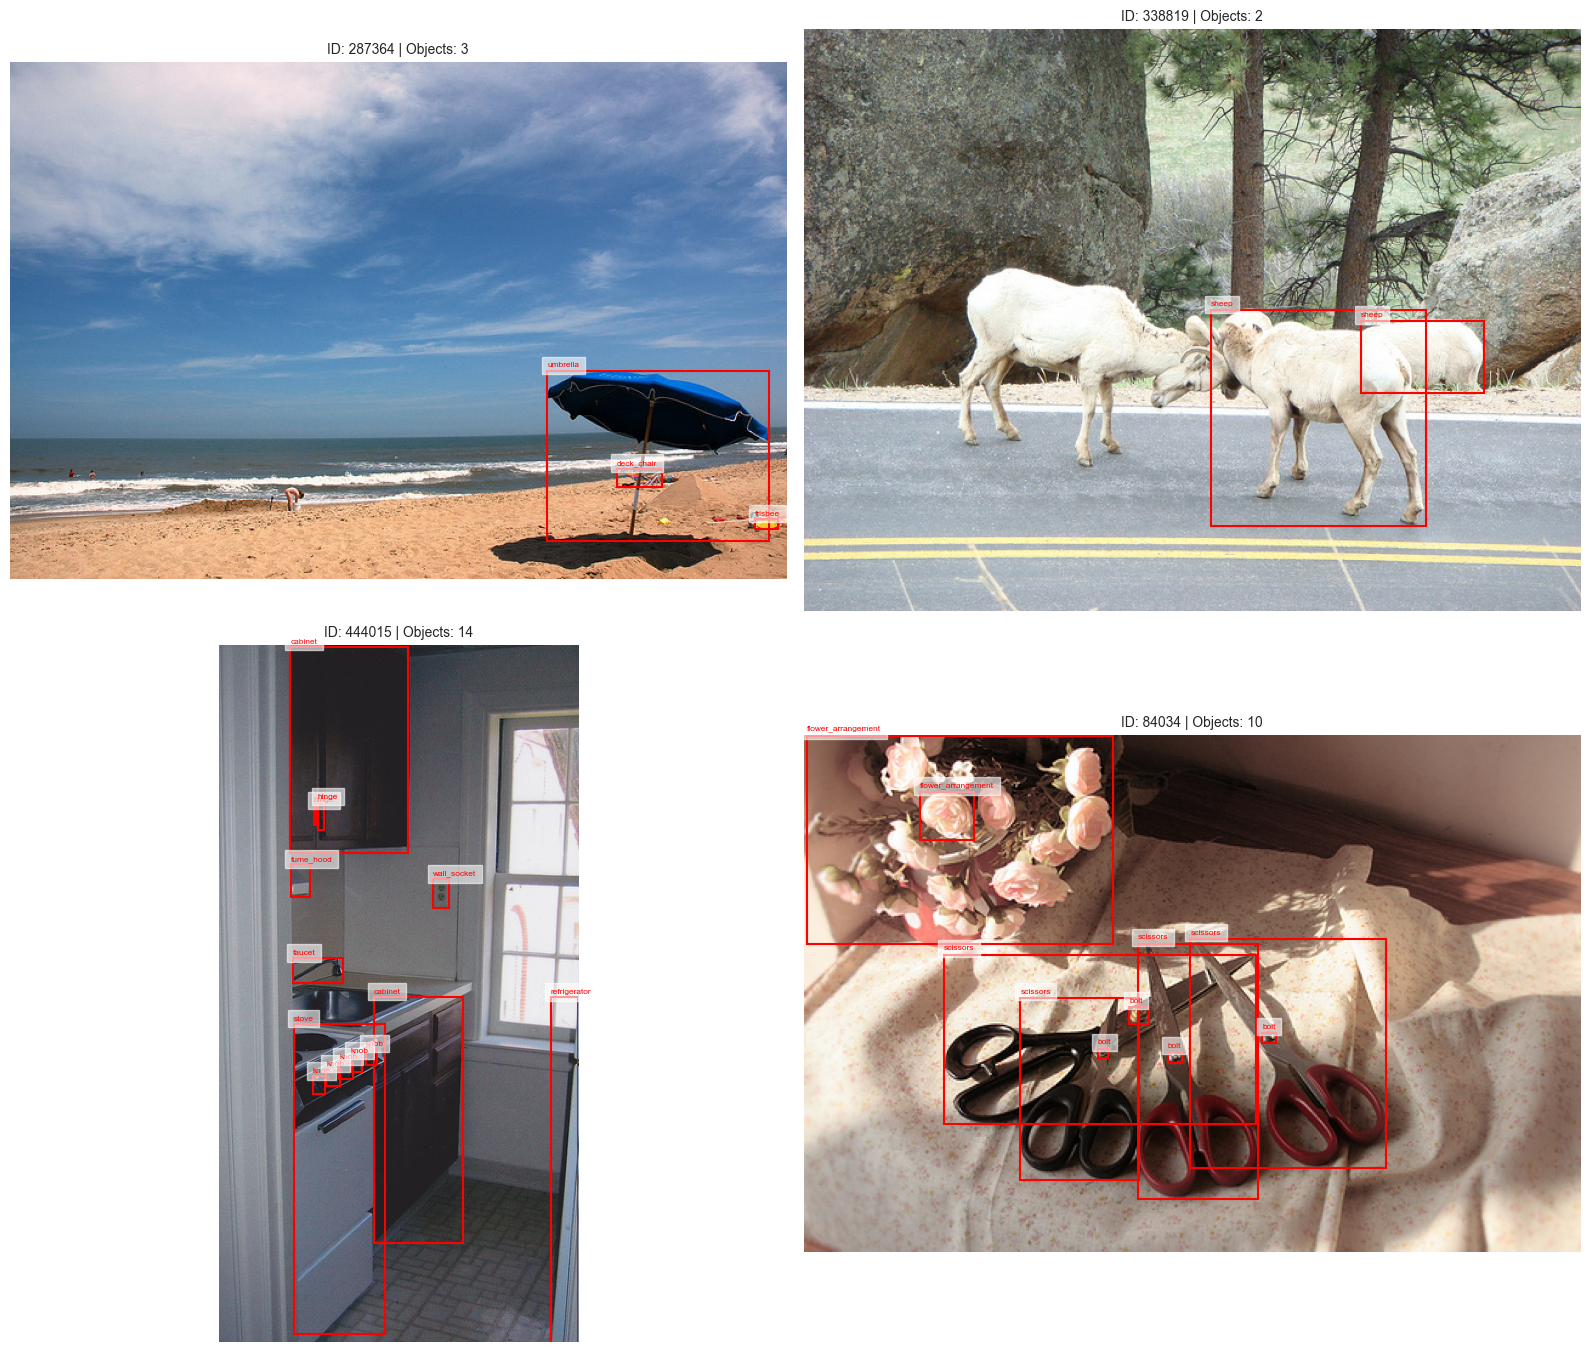

In [8]:
random_image_ids = random.sample(list(annotations_per_image.keys()), k=4)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, img_id in enumerate(random_image_ids):
    filename = f"{img_id:012d}.jpg"
    img_path = os.path.join("train2017", filename)
    
    if not os.path.exists(img_path):
        axes[idx].text(0.5, 0.5, f"Image not found: {filename}", 
                      ha='center', va='center', fontsize=10, color='red')
        axes[idx].set_title(f"ID: {img_id}")
        axes[idx].axis('off')
        continue
    
    try:
        img = Image.open(img_path)
        axes[idx].imshow(img)
        
        anns = annotations_per_image[img_id]
        for ann in anns:
            bbox = ann['bbox']
            category_name = category_id_to_category[ann['category_id']]['name']
            
            rect = patches.Rectangle(
                (bbox[0], bbox[1]), bbox[2], bbox[3],
                linewidth=1.5, edgecolor='r', facecolor='none'
            )
            axes[idx].add_patch(rect)
            axes[idx].text(bbox[0], bbox[1] - 3, category_name, 
                          color='red', fontsize=6, bbox=dict(facecolor='white', alpha=0.6))
        
        axes[idx].set_title(f"ID: {img_id} | Objects: {len(anns)}", fontsize=10)
        axes[idx].axis('off')
        
    except Exception as e:
        axes[idx].text(0.5, 0.5, f"Error: {str(e)}", 
                      ha='center', va='center', fontsize=9, color='red')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Section 6: Examine Annotation Statistics

In [7]:
objects_per_image = [len(anns) for anns in annotations_per_image.values()]
bbox_widths = []
bbox_heights = []
bbox_areas = []

for ann in lvis_data['annotations']:
    bbox = ann['bbox']
    bbox_widths.append(bbox[2])
    bbox_heights.append(bbox[3])
    bbox_areas.append(bbox[2] * bbox[3])

stats_df = pd.DataFrame({
    'Metric': [
        'Objects per Image (Mean)',
        'Objects per Image (Median)',
        'Objects per Image (Std)',
        'Objects per Image (Min)',
        'Objects per Image (Max)',
        'BBox Width (Mean)',
        'BBox Height (Mean)',
        'BBox Area (Mean)',
        'BBox Area (Median)',
    ],
    'Value': [
        f"{np.mean(objects_per_image):.2f}",
        f"{np.median(objects_per_image):.2f}",
        f"{np.std(objects_per_image):.2f}",
        f"{np.min(objects_per_image):.2f}",
        f"{np.max(objects_per_image):.2f}",
        f"{np.mean(bbox_widths):.2f}",
        f"{np.mean(bbox_heights):.2f}",
        f"{np.mean(bbox_areas):.2f}",
        f"{np.median(bbox_areas):.2f}",
    ]
})

print(stats_df.to_string(index=False))

                    Metric   Value
  Objects per Image (Mean)   12.78
Objects per Image (Median)    7.00
   Objects per Image (Std)   21.31
   Objects per Image (Min)    1.00
   Objects per Image (Max)  778.00
         BBox Width (Mean)   63.35
        BBox Height (Mean)   60.52
          BBox Area (Mean) 9220.62
        BBox Area (Median)  890.16
